# Signal level across minutes-bands — performance signals (X) by exposure *(population)*

*Read-only informative artifact. This notebook describes how each candidate
signal sits across minutes-bands (cameo → full game) — the X-side partner to
`points_by_minutes_band.ipynb`, which does the same for the target Y. It produces no
gate, no verdict, no test, and no causal or confound claim. It only describes
where each signal's level sits as minutes rise.*

## Questions this notebook answers (directive)

- **Determine** how each signal's typical level sits across minutes-bands
  (`1-29 / 30-59 / 60+`) — does it rise with time on the pitch or stay flat?
- **Establish** which signals move most from cameo to full-game appearances and
  which barely move.

Here the blocks are **minutes-bands** (cameo → full game) rather than gameweeks.

## Setup

Load the mart, restrict to the **whole season** (GW 1 to the latest completed GW)
and the **participation** population (`minutes > 0`), and split the minutes axis
into three bands: `1-29` (cameo), `30-59` (partial), and `60+` (secure). Bands
collapse at `60+` because FPL's scoring rules do not distinguish `60-89` from
`90` (same appearance / clean-sheet regime), so `60+` is the rule-aligned band.

We deliberately use the **whole featured range** (`minutes > 0`, cameos included),
because the point is to see how a signal sits *across* minutes — so no 60-minute
filter is imposed here.

**Double-gameweek (DGW) note.** DGW rows are **excluded for now**
(`is_dgw == False`): a DGW sums two fixtures into one player-gameweek (~180
minutes, doubled counts), which would otherwise inflate the `60+` band with
fixture-doubling. Per-fixture DGW treatment is the `fixture/` layer's job.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.block_distributions import (
    compute_signal_block_distributions,
)

try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

STUDY_GW_MIN = 1
STUDY_GW_MAX = _result.data_cutoff_gw

mart = _result.mart
df = mart[mart["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["is_dgw"] == False].copy()   # DGW excluded for now (single-fixture axis)

POSITIONS = ["GK", "DEF", "MID", "FWD"]

# Minutes-bands are the blocks here (cameo -> full game).
# compute_signal_block_distributions bins by whatever column we pass as gw_column,
# so we pass `minutes` and band ranges. Bands collapse at 60+ because FPL does not
# distinguish 60-89 from 90 (same appearance / clean-sheet regime); with DGW
# excluded, 60+ is a single full match (top bound 999 is just a safe ceiling).
MINUTES_BANDS = {"1-29": (1, 29), "30-59": (30, 59), "60+": (60, 999)}
BAND_ORDER = ["1-29", "30-59", "60+"]

# Same raw performance-signal universe as structure/signal.ipynb and the sibling
# population notebooks (numeric per-GW signals; exclude identity/market/structural/
# context/rolling). We keep the raw count signals -- the point is to see how they
# sit across minutes.
_EXCLUDE = {
    "player_id", "gw", "position_code", "team_id",
    "purchase_price", "minutes", "total_points",
    "is_bgw", "is_dgw", "is_warmup_gw",
    "fdr_avg", "xgc", "home_count", "away_count", "fixture_count",
    "is_live", "is_next", "is_previous", "finished",
    "transfers_in", "transfers_out", "ownership_count",
}
SIGNALS = sorted(
    c for c in df.select_dtypes(include="number").columns
    if c not in _EXCLUDE and "_roll" not in c and not c.endswith("_trend")
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.3f}".format)

print(f"Study range: GW {STUDY_GW_MIN} - GW {STUDY_GW_MAX} (whole season, from mart data_cutoff_gw)")
print(f"Population: minutes > 0, DGW excluded (participation, not a performance gate), n = {len(df):,} player-gameweeks")
print("Minutes-bands:", MINUTES_BANDS)
print(f"Signals ({len(SIGNALS)}):", SIGNALS)

Study range: GW 1 - GW 38 (whole season, from mart data_cutoff_gw)
Population: minutes > 0, DGW excluded (participation, not a performance gate), n = 11,190 player-gameweeks
Minutes-bands: {'1-29': (1, 29), '30-59': (30, 59), '60+': (60, 999)}
Signals (24): ['assists', 'bonus', 'bps', 'clean_sheets', 'clearances_blocks_interceptions', 'creativity', 'defensive_contribution', 'goals_conceded', 'goals_scored', 'ict_index', 'influence', 'own_goals', 'penalties_missed', 'penalties_saved', 'recoveries', 'red_cards', 'saves', 'starts', 'tackles', 'threat', 'xa', 'xg', 'xgi', 'yellow_cards']


## (a) Signal distribution across minutes-bands, by position

**What we measure** — for every (signal, position) pair, the signal's median /
IQR / p90 within each minutes-band, via `compute_signal_block_distributions`
(binning on `minutes` instead of gameweek). One row per (signal, position, band);
`n` per cell is shown so thin bands are visible.

**What it means** — this is each signal's level read three times along the minutes
axis. Reading a row left-to-right (`1-29` → `60+`) shows whether the signal's
typical level rises as the player spends more time on the pitch, or sits flat.

**What it doesn't mean** — this is a **description** of how the signal sits across
minutes-bands, season-pooled (DGW excluded). It is **not** a claim that minutes drives
or confounds the signal's relationship to points — explaining *why* a signal rises
with minutes, or what that does to its link with `total_points`, is a Diagnostic-tier
question, out of scope for this descriptive notebook.

**Guiding question (directive)** — *Determine how each signal's typical level sits
across minutes-bands — does it rise with minutes on the pitch, or stay flat?*

In [2]:
band_dist = compute_signal_block_distributions(
    df, SIGNALS, POSITIONS, gw_column="minutes", gw_blocks=MINUTES_BANDS,
)
# NOTE: the kernel is generic -- here 'min_gw'/'max_gw' are the minute-band bounds,
# and 'block' is the band name. Order for readability.
band_dist["block"] = pd.Categorical(band_dist["block"], categories=BAND_ORDER, ordered=True)
band_dist["position"] = pd.Categorical(band_dist["position"], categories=POSITIONS, ordered=True)
band_dist["signal"] = pd.Categorical(band_dist["signal"], categories=SIGNALS, ordered=True)
band_dist = band_dist.sort_values(["signal", "position", "block"]).reset_index(drop=True)
display(
    band_dist[["signal", "position", "block", "n", "median", "iqr", "p90"]]
    .rename(columns={"block": "minutes_band"})
)

,signal,position,minutes_band,n,median,iqr,p90
0,assists,GK,1-29,4,NaN,NaN,NaN
1,assists,GK,30-59,6,NaN,NaN,NaN
2,assists,GK,60+,737,0.000,0.000,0.000
3,assists,DEF,1-29,618,0.000,0.000,0.000
4,assists,DEF,30-59,283,0.000,0.000,0.000
...,...,...,...,...,...,...,...
283,yellow_cards,MID,30-59,597,0.000,0.000,1.000
284,yellow_cards,MID,60+,3184,0.000,0.000,1.000
285,yellow_cards,FWD,1-29,504,0.000,0.000,0.000
286,yellow_cards,FWD,30-59,144,0.000,0.000,0.000


In [ ]:
# Median-by-band pivot: read each (signal x position) row left-to-right to see how
# the signal's typical level moves from cameo (1-29) to full game (60+).
median_pivot = band_dist.pivot_table(
    index=["signal", "position"], columns="block", values="median", observed=True,
)[BAND_ORDER]
display(median_pivot.round(3))

## (b) How far each signal's level moves from cameo to full game

**What we measure** — a single descriptive number per signal: the mean over
positions of `median(60+) − median(1-29)` (`Δmedian`). It summarises how much the
signal's typical level moves from the shortest to the longest appearances. No
threshold, no verdict — just the size of the move.

**What it means** — a large positive `Δmedian` means the signal sits much higher in
full-game appearances than in cameos; near-zero means its typical level barely
depends on how long the player was on.

**What it doesn't mean** — still pure description. A large `Δmedian` is not a
statement about the signal's value, its link to points, or any confound — only that
its level co-moves with minutes in this season's data.

**Guiding question (directive)** — *Establish which signals move most from cameo to
full-game appearances and which barely move.*

In [4]:
# Descriptive band-to-band move per signal: mean over positions of
# [median(60+) - median(1-29)]. A compact "how much does this signal's typical level
# rise from cameo to full game" readout.
piv_full = band_dist.pivot_table(
    index=["signal", "position"], columns="block", values="median", observed=True,
)
delta = (piv_full["60+"] - piv_full["1-29"]).rename("delta_median")
delta_by_signal = (
    delta.reset_index().groupby("signal", observed=True)["delta_median"]
    .mean().sort_values(ascending=False)
)
print("Mean move in typical level from cameo (1-29) to full game (60+), per signal")
print("(averaged over positions; descriptive only):\n")
display(delta_by_signal.round(3).to_frame())

Mean move in typical level from cameo (1-29) to full game (60+), per signal
(averaged over positions; descriptive only):



,delta_median
signal,
influence,11.200
threat,10.000
bps,8.333
creativity,7.717
defensive_contribution,5.000
ict_index,3.267
recoveries,2.667
clearances_blocks_interceptions,2.333
goals_conceded,1.000


## (c) Signal level across minutes-bands — a visual read

**What we measure** — per (signal, position), the median (line) with its IQR band
and p90 across the three minutes-bands. One row per signal (own y-scale — `xgi`≈0.1
and `bps`≈10 don't share an axis); one column per position. Markers are the three
band values; lines only guide the eye.

**What it means** — a line that climbs left-to-right is a signal that sits higher
in longer appearances; a flat line is one whose level barely depends on minutes.

**What it doesn't mean** — description only; the climb (or its absence) is observed,
not explained or tested.

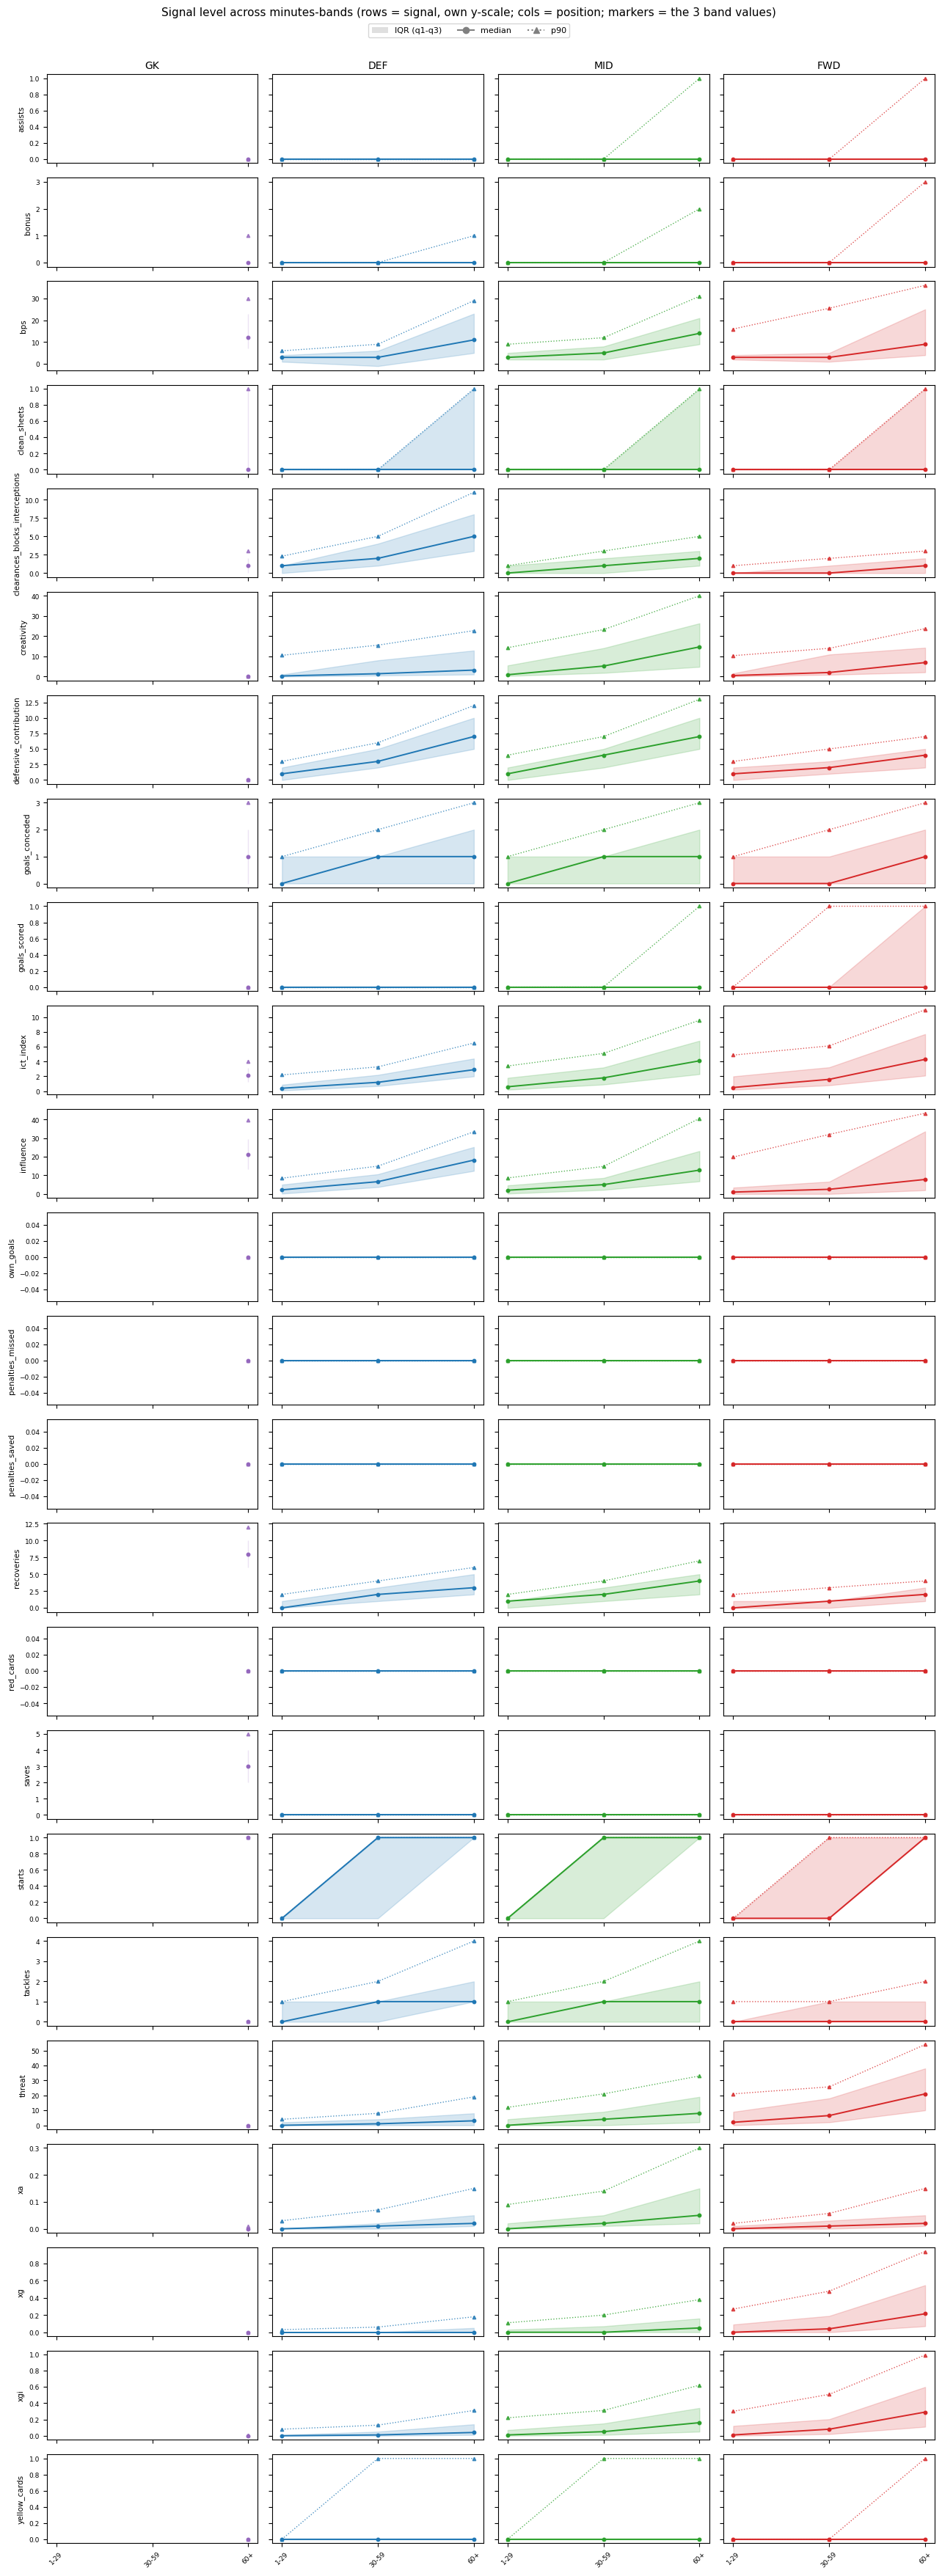

In [5]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

colours = {"GK": "#9467bd", "DEF": "#1f77b4", "MID": "#2ca02c", "FWD": "#d62728"}
x = np.arange(len(BAND_ORDER))
nrows = len(SIGNALS)
fig, axes = plt.subplots(nrows, len(POSITIONS), figsize=(13, 1.45 * nrows),
                         sharey="row", sharex=True)
for r, sig in enumerate(SIGNALS):
    for c, pos in enumerate(POSITIONS):
        ax = axes[r, c]
        sub = (band_dist[(band_dist["signal"] == sig) & (band_dist["position"] == pos)]
               .set_index("block").reindex(BAND_ORDER))
        q1 = sub["q1"].to_numpy(dtype=float)
        q3 = sub["q3"].to_numpy(dtype=float)
        med = sub["median"].to_numpy(dtype=float)
        p90 = sub["p90"].to_numpy(dtype=float)
        col = colours[pos]
        ax.fill_between(x, q1, q3, color=col, alpha=0.18)
        ax.plot(x, med, "-o", color=col, lw=1.4, ms=3.2)
        ax.plot(x, p90, ":^", color=col, lw=1.0, ms=3.2, alpha=0.8)
        if r == 0:
            ax.set_title(pos, fontsize=10)
        if c == 0:
            ax.set_ylabel(sig, fontsize=7.5)
        ax.set_xticks(x)
        ax.set_xticklabels(BAND_ORDER if r == nrows - 1 else [], fontsize=6.5, rotation=45)
        ax.tick_params(axis="y", labelsize=6.5)
legend_elems = [
    Patch(facecolor="grey", alpha=0.25, label="IQR (q1-q3)"),
    Line2D([0], [0], color="grey", marker="o", label="median"),
    Line2D([0], [0], color="grey", ls=":", marker="^", label="p90"),
]
fig.legend(handles=legend_elems, loc="upper center", ncol=3, fontsize=8,
           bbox_to_anchor=(0.5, 1.003))
fig.suptitle("Signal level across minutes-bands (rows = signal, own y-scale; "
             "cols = position; markers = the 3 band values)", y=1.008, fontsize=11)
plt.tight_layout()
plt.show()

## What the signal-by-minutes picture looks like

Plain-language description (not a verdict, not a test, not an explanation):

- **Most continuous signals sit higher the longer a player is on the pitch.** The
  clearest movers from cameo (`1-29`) to full game (`60+`) are the ICT family and
  BPS — `influence` (+11.2 median), `threat` (+10.0), `bps` (+8.3),
  `creativity` (+7.7), `ict_index` (+3.3) — followed by the defensive-action
  counts: `defensive_contribution` (+5.0), `recoveries` (+2.7),
  `clearances_blocks_interceptions` (+2.3), `tackles` (+0.7). These are all
  per-match accumulating quantities, so their typical level climbs band to band.
- **The rare-event signals look flat at the median — but that's a median
  artifact.** `goals_scored`, `assists`, `clean_sheets`, cards, `saves`,
  `penalties_*` all show `Δmedian = 0`, because their median is **0 in every band**
  (most appearances return none of these, regardless of minutes). Any movement for
  these lives in the **tail**, not the median — read the `p90` line in the facet
  plot, not the `Δmedian` table, for those.
- **The expected-goal signals barely move in median** — `xgi` (+0.16), `xg`
  (+0.09), `xa` (+0.03) — small-magnitude continuous signals whose typical level
  shifts only slightly across the bands.
- **Position shapes the picture** — e.g. `defensive_contribution` and the
  defensive counts climb at DEF/MID but are flat-zero at GK (read the per-position
  panels and the `n` column, not the position-averaged `Δmedian`).

All figures are **whole-season**, season-pooled over the **participation**
population (`minutes > 0`), with **DGW excluded** (`is_dgw == False`) so the `60+`
band is a single full match rather than fixture-doubled minutes. This notebook
**describes** how each signal sits across minutes-bands; *whether* minutes drives a
signal, or what that does to the signal's relationship with `total_points`, is a
Diagnostic-tier question, deliberately out of scope here.